In [2]:
# load Python packages
import numpy as np  # for numerical python libraries
import matplotlib.pyplot as plt  # for plotting
from scipy.stats import norm
import random

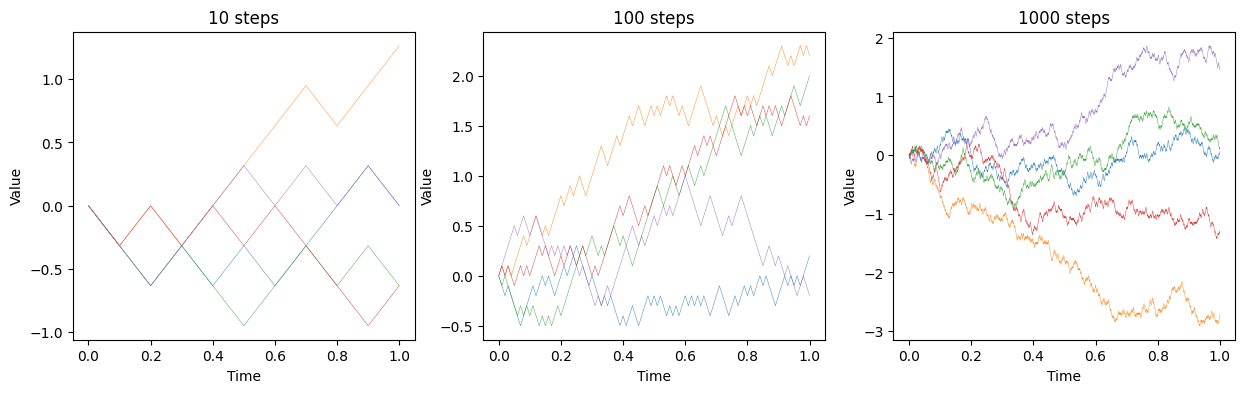

In [2]:
def sim_RW(T, Ndt, Nsims=10):
    # create time increment
    dt = T / Ndt
    
    # set the different times as a vector
    time = np.linspace(0, T, Ndt+1)
    
    # initialize the matrix for the RW
    X = np.zeros((Ndt+1,Nsims))
    
    # initial value of the process
    X[0,:] = 0
    
    # recursively simulate the process ( X[idx,:] is (1 , Nsims) )
    for i in range(Ndt):
        Z = np.array(random.choices([-1.0,1.0],k=Nsims))
        X[i+1,:] = X[i,:] + np.sqrt(dt) * Z
    
    return time, X

fig, axes = plt.subplots(1, 3, figsize=(15,4), sharex=True)

Ndt = [10,100,1000]
T=1
Npaths = 5

for i, col in enumerate(axes):
        np.random.seed(460)
        t, X = sim_RW(T,Ndt[i],Npaths)
        
        # plot the sample paths
        col.plot(t, X, linewidth=0.3)
        col.set_title(str(Ndt[i]) + r" steps")
        col.set_xlabel('Time')
        col.set_ylabel('Value')
plt.show()


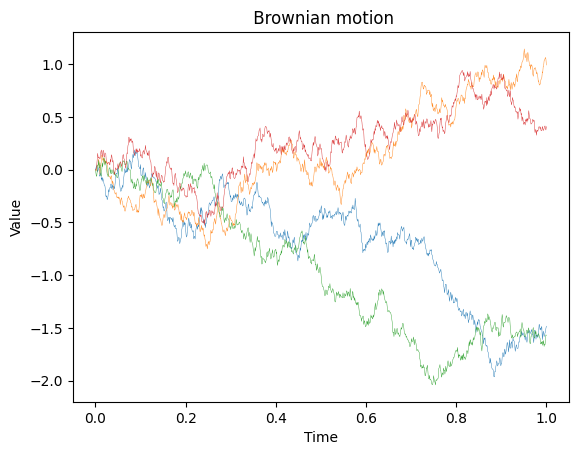

In [3]:
def sim_BM(T, Ndt, Nsims=10):
        
    # create time increment
    dt = T / Ndt
    
    # set the different times as a vector
    time = np.linspace(0, T, Ndt+1)
    
    # initialize the matrix for the RW
    W = np.zeros((Ndt+1,Nsims))
    
    # initial value of the process
    W[0,:] = 0
    
    # recursively simulate the process ( W[idx,:] is (1 , Nsims) )
    for i in range(Ndt):
        Z = np.random.normal(0,1,Nsims)
        W[i+1,:] = W[i,:] + np.sqrt(dt) * Z
    return time, W

np.random.seed(460)
Ndt = 1000
t, price = sim_BM(T,Ndt,Npaths)

        
# plot the sample paths
plt.plot(t, price[:,1:10], linewidth=0.3)
plt.title(r" Brownian motion")
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

We simulate 10,000 paths of Brownian motion from 0 to 1 using the random walk construction. The empirical mean at time 1 is approximately 0 and the empirical variance is approximately 1.

Mean of W_T: 0.0025879508905766596
Variance of W_T: 0.998469476171093


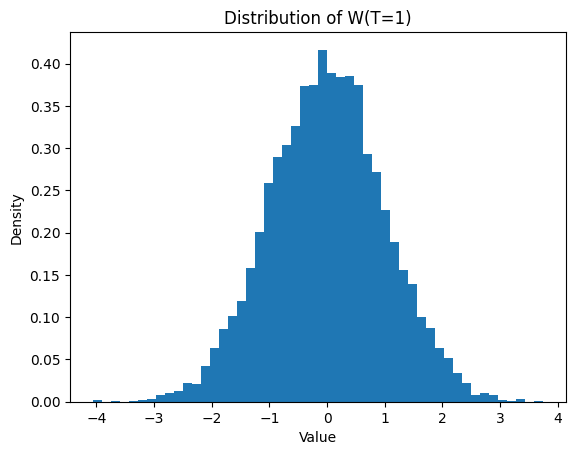

In [4]:
T = 1
Ndt = 1000
Nsims = 10000

dt = T / Ndt

# Time vector
time = np.linspace(0, T, Ndt + 1)

# Initialize matrix
W = np.zeros((Ndt + 1, Nsims))

# Simulate Brownian motion
for i in range(Ndt):
    Z = np.random.normal(0, 1, Nsims)
    W[i+1, :] = W[i, :] + np.sqrt(dt) * Z

# Extract values at T=1
W_T = W[-1, :]

# Calculate mean and variance
mean_WT = np.mean(W_T)
var_WT = np.var(W_T)

print("Mean of W_T:", mean_WT)
print("Variance of W_T:", var_WT)

# Plot histogram (kernel density approximation via histogram)
plt.figure()
plt.hist(W_T, bins=50, density=True)
plt.title("Distribution of W(T=1)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()
